In [1]:
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import friedmanchisquare
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

In [2]:
ensemble_metrics_dir = Path("./all_ensemble_metrics") #UY
us_ensemble_metrics_dir = Path("../extending_caravan/ensemble_metrics") #US

In [3]:
caravan_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_mm_day.csv")
chirps_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day.csv")
mswep_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_mswep_mm_day.csv")
gauge_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_gauge_mm_day.csv")
chirps_mswep_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day_prcp_mswep_mm_day.csv")
chirps_mswep_gauge_metrics = pd.read_csv(ensemble_metrics_dir / "precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day.csv")

In [4]:
caravan_metrics

,basin_id,NSE,MSE,RMSE,KGE,Alpha-NSE,Pearson-r,Beta-KGE,Beta-NSE,FHV,FMS,FLV,Peak-Timing,Missed-Peaks,Peak-MAPE
0,CAMELS_UY_10,-0.211190,1.715189,1.309652,0.302045,1.296814,0.628683,1.511045,0.400042,58.822231,-46.330570,-239.517975,2.352941,0.794872,58.392326
1,CAMELS_UY_11,0.132890,2.187165,1.478907,0.488914,1.031883,0.598678,1.314854,0.194575,-4.588153,27.194357,26.085201,1.250000,0.580000,54.427910
2,CAMELS_UY_15,0.326983,2.629820,1.621672,0.454949,0.787910,0.611816,1.318451,0.127778,-20.384392,-28.626118,1.521471,0.722222,0.586207,56.353020
3,CAMELS_UY_16,0.091909,7.356162,2.712225,0.313293,0.724794,0.433891,1.274496,0.108294,-31.849304,-26.364290,8.234345,1.090909,0.645161,68.524918
4,CAMELS_UY_2,0.315196,4.205149,2.050646,0.562248,1.254577,0.765134,1.267685,0.175147,35.324623,-40.042408,51.463665,1.789474,0.844444,48.307629
5,CAMELS_UY_3,0.384811,5.807536,2.409883,0.663976,1.017490,0.701416,1.153145,0.085266,4.480199,-42.099644,53.367180,0.904762,0.653061,64.526535
6,CAMELS_UY_5,0.443371,12.085149,3.476370,0.580976,0.847593,0.690584,1.237939,0.094255,-12.414746,-32.657986,71.149132,0.875000,0.703704,60.862793
7,CAMELS_UY_6,0.427339,5.517166,2.348865,0.651640,0.986548,0.716039,1.201345,0.110438,-3.332358,-39.208889,75.489861,1.400000,0.820513,53.524242
8,CAMELS_UY_7,0.145938,15.111301,3.887326,0.348190,0.903982,0.549455,1.461136,0.173994,-11.903933,-41.539242,59.499985,1.315789,0.836735,67.605133
9,CAMELS_UY_8,0.220763,12.174730,3.489231,0.285836,0.957086,0.612992,1.598676,0.191302,-6.902779,-29.405811,-90.644150,1.047619,0.666667,61.192829


In [5]:
nse_df = pd.DataFrame({
    'caravan':          caravan_metrics['NSE'].values,
    'chirps':           chirps_metrics['NSE'].values,
    'mswep':            mswep_metrics['NSE'].values,
    'gauge':            gauge_metrics['NSE'].values,
    'chirps_mswep':     chirps_mswep_metrics['NSE'].values,
    'chirps_mswep_gauge': chirps_mswep_gauge_metrics['NSE'].values,
}, index=caravan_metrics['basin_id'])  # use basin as index

nse_df

,caravan,chirps,mswep,gauge,chirps_mswep,chirps_mswep_gauge
basin_id,,,,,,
CAMELS_UY_10,-0.211190,0.440115,0.643053,0.256841,0.575763,0.497695
CAMELS_UY_11,0.132890,0.187004,-0.022436,0.354016,-0.001924,0.159634
CAMELS_UY_15,0.326983,0.623255,0.714225,0.758671,0.706826,0.809688
CAMELS_UY_16,0.091909,0.299137,0.328718,0.385586,0.220539,0.324008
CAMELS_UY_2,0.315196,0.687356,0.608003,0.449518,0.696400,0.661280
CAMELS_UY_3,0.384811,0.690190,0.660008,0.828253,0.755415,0.822933
CAMELS_UY_5,0.443371,0.615987,0.677971,0.790032,0.694556,0.795037
CAMELS_UY_6,0.427339,0.770925,0.722661,0.840887,0.803912,0.872821
CAMELS_UY_7,0.145938,0.532284,0.438709,0.548200,0.555920,0.599442


In [6]:
def build_metric_df(dataframes, names, metric, index_col='basin_id'):
    return pd.DataFrame(
        {name: df[metric].values for name, df in zip(names, dataframes)},
        index=dataframes[0][index_col]
    )

# Define once
dfs   = [caravan_metrics, chirps_metrics, mswep_metrics, 
         gauge_metrics, chirps_mswep_metrics, chirps_mswep_gauge_metrics]
names = ['caravan', 'chirps', 'mswep', 
         'gauge', 'chirps_mswep', 'chirps_mswep_gauge']

# Build for each metric
nse_df  = build_metric_df(dfs, names, 'NSE')
rmse_df = build_metric_df(dfs, names, 'RMSE')
mse_df  = build_metric_df(dfs, names, 'MSE')
kge_df  = build_metric_df(dfs, names, 'Beta-KGE')
fhv_df  = build_metric_df(dfs, names, 'FHV')
fms_df  = build_metric_df(dfs, names, 'FMS')
flv_df  = build_metric_df(dfs, names, 'FLV')
peak_timing_df  = build_metric_df(dfs, names, 'Peak-Timing')
missed_peaks_df  = build_metric_df(dfs, names, 'Missed-Peaks')
peak_mape_df  = build_metric_df(dfs, names, 'Peak-MAPE')

def shapiro_test(df, metric_name):
    print(f"\nShapiro-Wilk — {metric_name}")
    print("=" * 45)
    for model in df.columns:
        stat, p = stats.shapiro(df[model])
        normal = "Normal" if p > 0.05 else "Non-normal"
        print(f"{model:20s}  W={stat:.4f}  p={p:.4f}  {normal}")

shapiro_test(nse_df,         'NSE')
shapiro_test(rmse_df,        'RMSE')
shapiro_test(mse_df,         'MSE')
shapiro_test(kge_df,         'Beta-KGE')  # kge_df → Beta-KGE
shapiro_test(fhv_df,         'FHV')       # fhv_df → FHV
shapiro_test(fms_df,         'FMS')       # fms_df → FMS
shapiro_test(flv_df,         'FLV')
shapiro_test(peak_timing_df, 'Peak-Timing')
shapiro_test(missed_peaks_df,'Missed-Peaks')
shapiro_test(peak_mape_df,   'Peak-MAPE')


Shapiro-Wilk — NSE
caravan               W=0.8854  p=0.1217  Normal
chirps                W=0.9142  p=0.2733  Normal
mswep                 W=0.8314  p=0.0244  Non-normal
gauge                 W=0.9009  p=0.1896  Normal
chirps_mswep          W=0.7813  p=0.0053  Non-normal
chirps_mswep_gauge    W=0.8703  p=0.0783  Normal

Shapiro-Wilk — RMSE
caravan               W=0.9221  p=0.3366  Normal
chirps                W=0.8659  p=0.0687  Normal
mswep                 W=0.9588  p=0.7567  Normal
gauge                 W=0.8845  p=0.1185  Normal
chirps_mswep          W=0.8981  p=0.1751  Normal
chirps_mswep_gauge    W=0.9002  p=0.1858  Normal

Shapiro-Wilk — MSE
caravan               W=0.8759  p=0.0924  Normal
chirps                W=0.8143  p=0.0145  Non-normal
mswep                 W=0.9067  p=0.2230  Normal
gauge                 W=0.8546  p=0.0489  Non-normal
chirps_mswep          W=0.8506  p=0.0435  Non-normal
chirps_mswep_gauge    W=0.8633  p=0.0635  Normal

Shapiro-Wilk — Beta-KGE
caravan     

In [7]:
nse_df

,caravan,chirps,mswep,gauge,chirps_mswep,chirps_mswep_gauge
basin_id,,,,,,
CAMELS_UY_10,-0.211190,0.440115,0.643053,0.256841,0.575763,0.497695
CAMELS_UY_11,0.132890,0.187004,-0.022436,0.354016,-0.001924,0.159634
CAMELS_UY_15,0.326983,0.623255,0.714225,0.758671,0.706826,0.809688
CAMELS_UY_16,0.091909,0.299137,0.328718,0.385586,0.220539,0.324008
CAMELS_UY_2,0.315196,0.687356,0.608003,0.449518,0.696400,0.661280
CAMELS_UY_3,0.384811,0.690190,0.660008,0.828253,0.755415,0.822933
CAMELS_UY_5,0.443371,0.615987,0.677971,0.790032,0.694556,0.795037
CAMELS_UY_6,0.427339,0.770925,0.722661,0.840887,0.803912,0.872821
CAMELS_UY_7,0.145938,0.532284,0.438709,0.548200,0.555920,0.599442


In [8]:
def friedman_test(df, metric_name):
    data = [df[col].values for col in df.columns]
    stat, p = friedmanchisquare(*data)
    
    # Kendall's W effect size
    k = len(df.columns)  # number of models
    n = len(df)          # number of catchments
    W = stat / (n * (k - 1))
    
    # Effect size interpretation
    if W < 0.1:
        effect = "negligible"
    elif W < 0.3:
        effect = "small"
    elif W < 0.5:
        effect = "moderate"
    else:
        effect = "large"
    
    print(f"\n{'='*55}")
    print(f"  Friedman Test — {metric_name}")
    print(f"{'='*55}")
    print(f"  χ²        = {stat:.4f}")
    print(f"  p-value   = {p:.4f}")
    print(f"  Kendall W = {W:.4f} ({effect} effect)")
    print(f"  n catchments = {n}, k models = {k}")
    print(f"\n  {'Significant difference between models (p < 0.05)' if p < 0.05 else 'No significant difference between models (p >= 0.05)'}")
    
    return stat, p, W

# Run for all metrics
results = {}
for metric, df in zip(['NSE', 'RMSE', 'MSE', 'Beta-KGE','FHV','FMS','FLV','Peak-Timing','Missed-Peaks','Peak-MAPE'], 
                       [nse_df, rmse_df, mse_df, kge_df, fhv_df, fms_df, flv_df, peak_timing_df, missed_peaks_df, peak_mape_df]):
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — NSE
  χ²        = 29.8571
  p-value   = 0.0000
  Kendall W = 0.5429 (large effect)
  n catchments = 11, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — RMSE
  χ²        = 29.8571
  p-value   = 0.0000
  Kendall W = 0.5429 (large effect)
  n catchments = 11, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — MSE
  χ²        = 29.8571
  p-value   = 0.0000
  Kendall W = 0.5429 (large effect)
  n catchments = 11, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — Beta-KGE
  χ²        = 33.3896
  p-value   = 0.0000
  Kendall W = 0.6071 (large effect)
  n catchments = 11, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — FHV
  χ²        = 26.5325
  p-value   = 0.0001
  Kendall W = 0.4824 (moderate effect)
  n catchments = 11, k models = 6

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²        = 36.0909
  p-va

In [9]:
metric_dfs = {
    'NSE':          nse_df,
    'RMSE':         rmse_df,
    'MSE':          mse_df,
    'Beta-KGE':     kge_df,
    'FHV':          fhv_df,
    'FMS':          fms_df,
    'FLV':          flv_df,
    'Peak-Timing':  peak_timing_df,
    'Missed-Peaks': missed_peaks_df,
    'Peak-MAPE':    peak_mape_df,
}


friedman_ps = {
    'NSE':          0.0000,
    'RMSE':         0.0000,
    'MSE':          0.0000,
    'Beta-KGE':     0.0000,
    'FHV':          0.0001,
    'FMS':          0.0000,
    'FLV':          0.0640,
    'Peak-Timing':  0.0000,
    'Missed-Peaks': 0.0000,
    'Peak-MAPE':    0.0000,
}

In [10]:
def posthoc_wilcoxon(df, metric_name, friedman_p):
    if friedman_p >= 0.05:
        print(f"\nSkipping post-hoc for {metric_name} — Friedman not significant (p={friedman_p:.4f})")
        return None
    
    models = df.columns.tolist()
    pairs = list(itertools.combinations(models, 2))
    
    rows = []
    for m1, m2 in pairs:
        # Uses paired differences — respects your blocked design
        stat, p_raw = wilcoxon(df[m1].values, df[m2].values)
        rows.append({'model_1': m1, 'model_2': m2, 'p_raw': p_raw})
    
    results_df = pd.DataFrame(rows)
    
    # Bonferroni correction
    _, p_corrected, _, _ = multipletests(results_df['p_raw'], method='bonferroni')
    results_df['p_corrected'] = p_corrected
    results_df['significant'] = p_corrected < 0.05
    
    print(f"\n{'='*65}")
    print(f"  Wilcoxon signed-rank + Bonferroni — {metric_name}")
    print(f"{'='*65}")
    for _, row in results_df.iterrows():
        sig = "❌ different" if row['significant'] else "✅ similar"
        print(f"  {row['model_1']:20s} vs {row['model_2']:20s}  "
              f"p_raw={row['p_raw']:.4f}  p_adj={row['p_corrected']:.4f}  {sig}")
    
    return results_df

# Run for all metrics
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric])
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — NSE
  caravan              vs chirps                p_raw=0.0010  p_adj=0.0146  ❌ different
  caravan              vs mswep                 p_raw=0.0020  p_adj=0.0293  ❌ different
  caravan              vs gauge                 p_raw=0.0010  p_adj=0.0146  ❌ different
  caravan              vs chirps_mswep          p_raw=0.0029  p_adj=0.0439  ❌ different
  caravan              vs chirps_mswep_gauge    p_raw=0.0010  p_adj=0.0146  ❌ different
  chirps               vs mswep                 p_raw=0.8311  p_adj=1.0000  ✅ similar
  chirps               vs gauge                 p_raw=0.3203  p_adj=1.0000  ✅ similar
  chirps               vs chirps_mswep          p_raw=0.1748  p_adj=1.0000  ✅ similar
  chirps               vs chirps_mswep_gauge    p_raw=0.0098  p_adj=0.1465  ✅ similar
  mswep                vs gauge                 p_raw=0.4131  p_adj=1.0000  ✅ similar
  mswep                vs chirps_mswep          p_raw=0.3652  p_adj=1.0000  ✅ similar
 

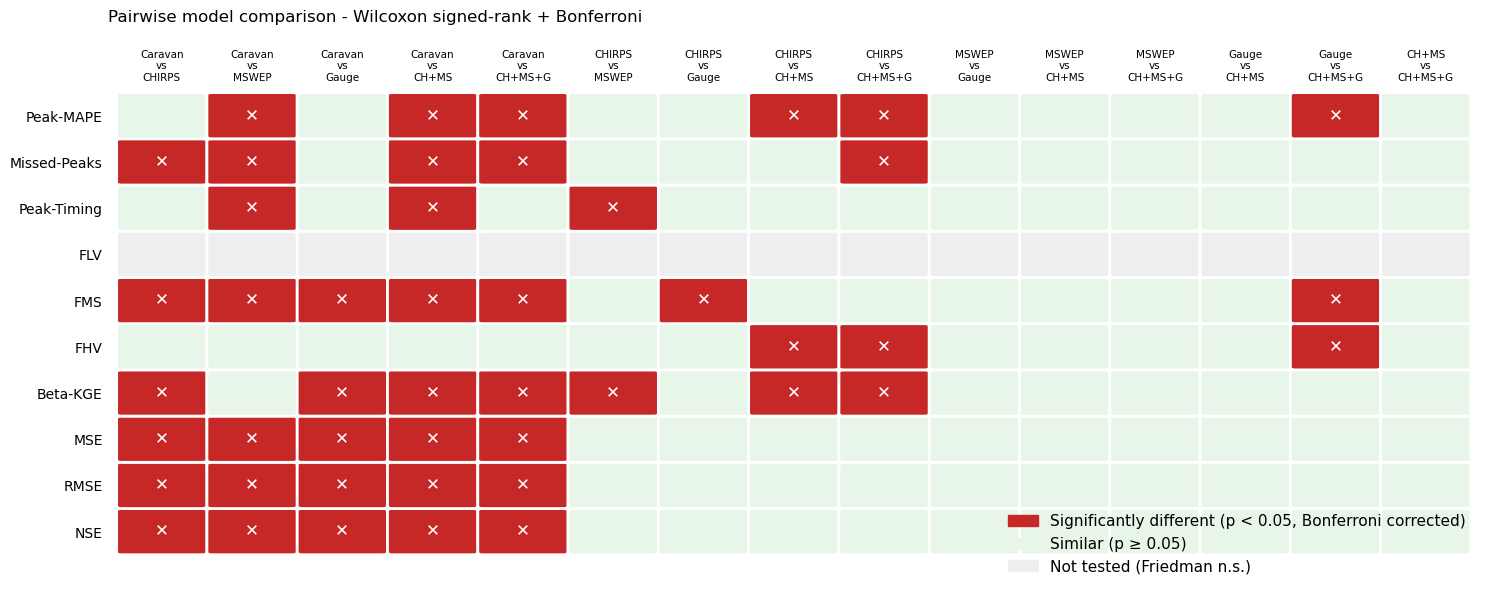

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import itertools

models = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep', 'chirps_mswep_gauge']
short_names = ['Caravan', 'CHIRPS', 'MSWEP', 'Gauge', 'CH+MS', 'CH+MS+G']

# Significant pairs from your new Wilcoxon results
sig_pairs = {
    'NSE':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'), 
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'RMSE':         [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'MSE':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'Beta-KGE':     [('caravan','chirps'), ('caravan','gauge'), ('caravan','chirps_mswep'),
                     ('caravan','chirps_mswep_gauge'), ('chirps','mswep'),
                     ('chirps','chirps_mswep'), ('chirps','chirps_mswep_gauge')],
    'FHV':          [('chirps','chirps_mswep'), ('chirps','chirps_mswep_gauge'),
                     ('gauge','chirps_mswep_gauge')],
    'FMS':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge'),
                     ('chirps','gauge'), ('gauge','chirps_mswep_gauge')],
    'FLV':          None,
    'Peak-Timing':  [('caravan','mswep'), ('caravan','chirps_mswep'),
                     ('chirps','mswep')],
    'Missed-Peaks': [('caravan','chirps'), ('caravan','mswep'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge'),
                     ('chirps','chirps_mswep_gauge')],
    'Peak-MAPE':    [('caravan','mswep'), ('caravan','chirps_mswep'),
                     ('caravan','chirps_mswep_gauge'), ('chirps','chirps_mswep'),
                     ('chirps','chirps_mswep_gauge'), ('gauge','chirps_mswep_gauge')],
}

metrics_list = list(sig_pairs.keys())
pairs = list(itertools.combinations(range(len(models)), 2))
pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]

# Build matrix: 0=similar, 1=different, 2=skipped
matrix = np.zeros((len(metrics_list), len(pairs)))
for m_idx, metric in enumerate(metrics_list):
    sp = sig_pairs[metric]
    if sp is None:
        matrix[m_idx, :] = 2
    else:
        sig_set = {(a, b) for a, b in sp} | {(b, a) for a, b in sp}
        for p_idx, (i, j) in enumerate(pairs):
            if (models[i], models[j]) in sig_set:
                matrix[m_idx, p_idx] = 1

# Plot
fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor('white')

colors = {0: '#e8f5e9', 1: '#c62828', 2: '#eeeeee'}

for m_idx in range(len(metrics_list)):
    for p_idx in range(len(pairs)):
        val = matrix[m_idx, p_idx]
        rect = mpatches.FancyBboxPatch(
            (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[val],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)
        if val == 1:
            ax.text(p_idx, m_idx, '✕', ha='center', va='center',
                    fontsize=12, color='white', fontweight='bold')

ax.set_xlim(-0.6, len(pairs) - 0.4)
ax.set_ylim(-0.6, len(metrics_list) - 0.4)
ax.set_xticks(range(len(pairs)))
ax.set_xticklabels(pair_labels, fontsize=7.5, ha='center')
ax.set_yticks(range(len(metrics_list)))
ax.set_yticklabels(metrics_list, fontsize=10)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(color=colors[1], label='Significantly different (p < 0.05, Bonferroni corrected)'),
    mpatches.Patch(color=colors[0], label='Similar (p ≥ 0.05)'),
    mpatches.Patch(color=colors[2], label='Not tested (Friedman n.s.)'),
]
ax.legend(handles=legend_patches, loc='lower right',
          bbox_to_anchor=(1, -0.06), frameon=False, fontsize=11)

ax.set_title('Pairwise model comparison - Wilcoxon signed-rank + Bonferroni',
             fontsize=12, pad=20, loc='left', fontweight='normal')

plt.tight_layout()
# plt.savefig('wilcoxon_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

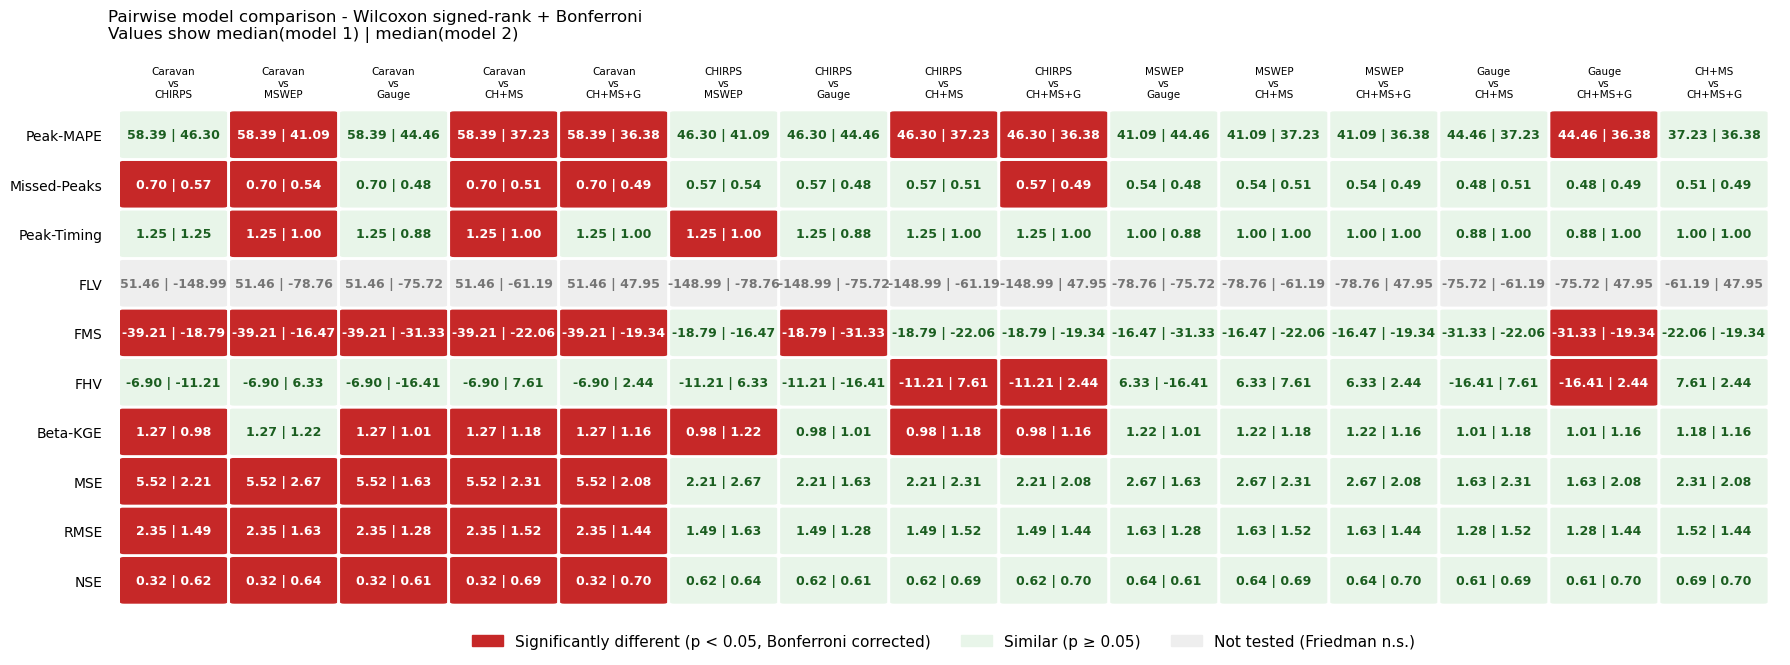

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import itertools

models = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep', 'chirps_mswep_gauge']
short_names = ['Caravan', 'CHIRPS', 'MSWEP', 'Gauge', 'CH+MS', 'CH+MS+G']

sig_pairs = {
    'NSE':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'), 
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'RMSE':         [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'MSE':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'Beta-KGE':     [('caravan','chirps'), ('caravan','gauge'), ('caravan','chirps_mswep'),
                     ('caravan','chirps_mswep_gauge'), ('chirps','mswep'),
                     ('chirps','chirps_mswep'), ('chirps','chirps_mswep_gauge')],
    'FHV':          [('chirps','chirps_mswep'), ('chirps','chirps_mswep_gauge'),
                     ('gauge','chirps_mswep_gauge')],
    'FMS':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge'),
                     ('chirps','gauge'), ('gauge','chirps_mswep_gauge')],
    'FLV':          None,
    'Peak-Timing':  [('caravan','mswep'), ('caravan','chirps_mswep'),
                     ('chirps','mswep')],
    'Missed-Peaks': [('caravan','chirps'), ('caravan','mswep'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge'),
                     ('chirps','chirps_mswep_gauge')],
    'Peak-MAPE':    [('caravan','mswep'), ('caravan','chirps_mswep'),
                     ('caravan','chirps_mswep_gauge'), ('chirps','chirps_mswep'),
                     ('chirps','chirps_mswep_gauge'), ('gauge','chirps_mswep_gauge')],
}

metrics_list = list(sig_pairs.keys())
pairs = list(itertools.combinations(range(len(models)), 2))
pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]

# ── NEW: median lookup ────────────────────────────────────────────────────────
median_vals = {metric: df.median() for metric, df in metric_dfs.items()}
# ─────────────────────────────────────────────────────────────────────────────

# Build matrix: 0=similar, 1=different, 2=skipped
matrix = np.zeros((len(metrics_list), len(pairs)))
for m_idx, metric in enumerate(metrics_list):
    sp = sig_pairs[metric]
    if sp is None:
        matrix[m_idx, :] = 2
    else:
        sig_set = {(a, b) for a, b in sp} | {(b, a) for a, b in sp}
        for p_idx, (i, j) in enumerate(pairs):
            if (models[i], models[j]) in sig_set:
                matrix[m_idx, p_idx] = 1

# Plot
fig, ax = plt.subplots(figsize=(18, 7))  # slightly wider to fit text
fig.patch.set_facecolor('white')

colors = {0: '#e8f5e9', 1: '#c62828', 2: '#eeeeee'}
text_colors = {0: '#1b5e20', 1: 'white', 2: '#757575'}

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        val = matrix[m_idx, p_idx]

        rect = mpatches.FancyBboxPatch(
            (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[val],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        # ── NEW: median labels ────────────────────────────────────────────
        med_i = median_vals[metric][models[i]]
        med_j = median_vals[metric][models[j]]
        label = f"{med_i:.2f} | {med_j:.2f}"

        ax.text(p_idx, m_idx, label,
                ha='center', va='center',
                fontsize=9, color=text_colors[val],
                fontweight='bold') #, linespacing=1.2)
        # ─────────────────────────────────────────────────────────────────

ax.set_xlim(-0.6, len(pairs) - 0.4)
ax.set_ylim(-0.6, len(metrics_list) - 0.4)
ax.set_xticks(range(len(pairs)))
ax.set_xticklabels(pair_labels, fontsize=7.5, ha='center')
ax.set_yticks(range(len(metrics_list)))
ax.set_yticklabels(metrics_list, fontsize=10)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(color=colors[1], label='Significantly different (p < 0.05, Bonferroni corrected)'),
    mpatches.Patch(color=colors[0], label='Similar (p ≥ 0.05)'),
    mpatches.Patch(color=colors[2], label='Not tested (Friedman n.s.)'),
]
# ax.legend(handles=legend_patches, loc='lower right',
#           bbox_to_anchor=(1, -0.06), frameon=False, fontsize=11)

ax.set_title('Pairwise model comparison - Wilcoxon signed-rank + Bonferroni\n'
             'Values show median(model 1) | median(model 2)',
             fontsize=12, pad=20, loc='left', fontweight='normal')

ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.02),   # centered below the axes
          ncol=3,                          # all 3 patches in one row
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)          # add breathing room below the plot
plt.show()

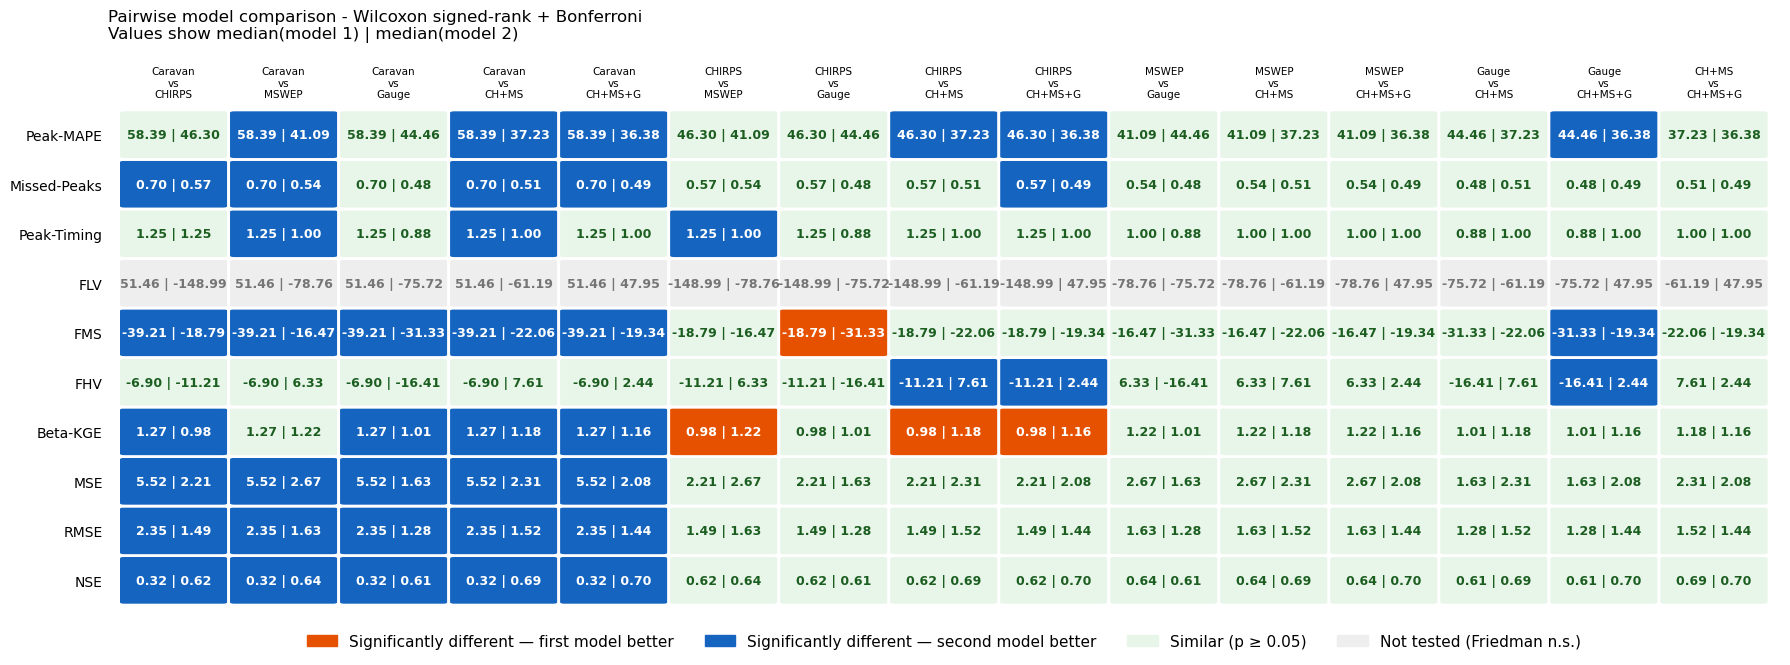

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import itertools

models = ['caravan', 'chirps', 'mswep', 'gauge', 'chirps_mswep', 'chirps_mswep_gauge']
short_names = ['Caravan', 'CHIRPS', 'MSWEP', 'Gauge', 'CH+MS', 'CH+MS+G']

sig_pairs = {
    'NSE':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'), 
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'RMSE':         [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'MSE':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge')],
    'Beta-KGE':     [('caravan','chirps'), ('caravan','gauge'), ('caravan','chirps_mswep'),
                     ('caravan','chirps_mswep_gauge'), ('chirps','mswep'),
                     ('chirps','chirps_mswep'), ('chirps','chirps_mswep_gauge')],
    'FHV':          [('chirps','chirps_mswep'), ('chirps','chirps_mswep_gauge'),
                     ('gauge','chirps_mswep_gauge')],
    'FMS':          [('caravan','chirps'), ('caravan','mswep'), ('caravan','gauge'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge'),
                     ('chirps','gauge'), ('gauge','chirps_mswep_gauge')],
    'FLV':          None,
    'Peak-Timing':  [('caravan','mswep'), ('caravan','chirps_mswep'),
                     ('chirps','mswep')],
    'Missed-Peaks': [('caravan','chirps'), ('caravan','mswep'),
                     ('caravan','chirps_mswep'), ('caravan','chirps_mswep_gauge'),
                     ('chirps','chirps_mswep_gauge')],
    'Peak-MAPE':    [('caravan','mswep'), ('caravan','chirps_mswep'),
                     ('caravan','chirps_mswep_gauge'), ('chirps','chirps_mswep'),
                     ('chirps','chirps_mswep_gauge'), ('gauge','chirps_mswep_gauge')],
}

# Target value for "best" per metric
metric_targets = {
    'NSE':          1,
    'RMSE':         0,
    'MSE':          0,
    'Beta-KGE':     1,
    'FHV':          0,
    'FMS':          0,
    'FLV':          0,
    'Peak-Timing':  0,
    'Missed-Peaks': 0,
    'Peak-MAPE':    0,
}

def better_model(metric, med_i, med_j):
    """Returns 'first', 'second', or 'tie' based on closeness to target."""
    target = metric_targets[metric]
    dist_i = abs(med_i - target)
    dist_j = abs(med_j - target)
    if dist_i < dist_j:
        return 'first'
    elif dist_j < dist_i:
        return 'second'
    else:
        return 'tie'

metrics_list = list(sig_pairs.keys())
pairs = list(itertools.combinations(range(len(models)), 2))
pair_labels = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]

median_vals = {metric: df.median() for metric, df in metric_dfs.items()}

# Build matrix: 0=similar, 1=different, 2=skipped
matrix = np.zeros((len(metrics_list), len(pairs)))
for m_idx, metric in enumerate(metrics_list):
    sp = sig_pairs[metric]
    if sp is None:
        matrix[m_idx, :] = 2
    else:
        sig_set = {(a, b) for a, b in sp} | {(b, a) for a, b in sp}
        for p_idx, (i, j) in enumerate(pairs):
            if (models[i], models[j]) in sig_set:
                matrix[m_idx, p_idx] = 1

# Plot
fig, ax = plt.subplots(figsize=(18, 7))
fig.patch.set_facecolor('white')

colors = {
    0:        '#e8f5e9',   # similar   → light green
    2:        '#eeeeee',   # skipped   → grey
    'first':  '#e65100',   # first model better  → orange
    'second': '#1565c0',   # second model better → blue
    'tie':    '#6a1de8',   # tie (rare)           → purple
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        val = matrix[m_idx, p_idx]

        med_i = median_vals[metric][models[i]]
        med_j = median_vals[metric][models[j]]

        # Determine cell color key
        if val == 1:
            winner = better_model(metric, med_i, med_j)
            color_key = winner
        else:
            color_key = val   # 0 or 2

        rect = mpatches.FancyBboxPatch(
            (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f} | {med_j:.2f}"
        ax.text(p_idx, m_idx, label,
                ha='center', va='center',
                fontsize=9, color=text_colors[color_key],
                fontweight='bold')

ax.set_xlim(-0.6, len(pairs) - 0.4)
ax.set_ylim(-0.6, len(metrics_list) - 0.4)
ax.set_xticks(range(len(pairs)))
ax.set_xticklabels(pair_labels, fontsize=7.5, ha='center')
ax.set_yticks(range(len(metrics_list)))
ax.set_yticklabels(metrics_list, fontsize=10)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(color=colors['first'],  label='Significantly different — first model better'),
    mpatches.Patch(color=colors['second'], label='Significantly different — second model better'),
    mpatches.Patch(color=colors[0],        label='Similar (p ≥ 0.05)'),
    mpatches.Patch(color=colors[2],        label='Not tested (Friedman n.s.)'),
]

ax.set_title('Pairwise model comparison - Wilcoxon signed-rank + Bonferroni\n'
             'Values show median(model 1) | median(model 2)',
             fontsize=12, pad=20, loc='left', fontweight='normal')

ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.02),
          ncol=4,
          frameon=False, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()

# US (CHIRPS_v2 or CHIRPS_v3)

In [71]:
# US
run_metrics = ['camels_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CAMELS
               "total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CARAVAN
               'chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CHIRPS
               # 'chirps_v3_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #CHIRPS_v3
               'mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5', #MSWEP
               'mswep_precipitation_chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5' #MSWEP + CHIRPS
            #    'mswep_precipitation_chirps_v3_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5' #MSWEP + CHIRPS_v3
               ] 

In [72]:
# # US
# run_metrics = ['154_camels_30_epochs_seq_270_hidden_256_dropout_04_fb_05_seed111_1103_063301',
#                "caravan_154_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0103_211409",
#                'precip_chirps_precipitation_0503_093821',
#                'precip_mswep_precipitation_0503_110038',
#             #    'precip_total_precipitation_sum_chirps_precipitation_0303_072447',
#             #    'precip_total_precipitation_sum_mswep_precipitation_0303_084843',
#                'precip_chirps_precipitation_mswep_precipitation_0303_101255']

In [73]:
model_labels = [
    'camels', 'caravan', 'chirps', 'mswep', 'chirps_mswep'
]

metric_names = [
    'Peak-MAPE', 'Missed-Peaks', 'Peak-Timing',
    'FLV', 'FMS', 'FHV',
    'Beta-KGE', 'MSE', 'RMSE', 'NSE'
]

In [74]:
# ── Load data ────────────────────────────────────────────────────────────────
all_metrics = {m: [] for m in metric_names}
basins_order = []

for i, run_name in enumerate(run_metrics):
    metrics_csv = pd.read_csv(us_ensemble_metrics_dir / f"{run_name}.csv")

    if i == 0:
        basins_order = metrics_csv["basin_id"].values

    for metric in metric_names:
        all_metrics[metric].append(metrics_csv[metric].values)

# ── Build per-metric DataFrames ───────────────────────────────────────────────
metric_dfs = {
    metric: pd.DataFrame(
        dict(zip(model_labels, arrays)),
        index=basins_order
    )
    for metric, arrays in all_metrics.items()
}

In [75]:
# ── Friedman test ─────────────────────────────────────────────────────────────
def friedman_test(df, metric_name):
    data = [df[col].dropna().values for col in df.columns]
    stat, p = friedmanchisquare(*data)

    k = len(df.columns)
    n = len(df)
    W = stat / (n * (k - 1))

    if W < 0.1:
        effect = "negligible"
    elif W < 0.3:
        effect = "small"
    elif W < 0.5:
        effect = "moderate"
    else:
        effect = "large"

    print(f"\n{'='*55}")
    print(f"  Friedman Test — {metric_name}")
    print(f"{'='*55}")
    print(f"  χ²           = {stat:.4f}")
    print(f"  p-value      = {p:.4f}")
    print(f"  Kendall W    = {W:.4f} ({effect} effect)")
    print(f"  n catchments = {n}, k models = {k}")
    print(f"\n  {'Significant difference between models (p < 0.05)' if p < 0.05 else 'No significant difference between models (p >= 0.05)'}")

    return stat, p, W

In [76]:
# ── Run for all metrics ───────────────────────────────────────────────────────
results = {}
for metric, df in metric_dfs.items():
    stat, p, W = friedman_test(df, metric)
    results[metric] = {'stat': stat, 'p': p, 'W': W}


  Friedman Test — Peak-MAPE
  χ²           = 327.4130
  p-value      = 0.0000
  Kendall W    = 0.5315 (large effect)
  n catchments = 154, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Missed-Peaks
  χ²           = 406.8331
  p-value      = 0.0000
  Kendall W    = 0.6604 (large effect)
  n catchments = 154, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — Peak-Timing
  χ²           = 213.8791
  p-value      = 0.0000
  Kendall W    = 0.3472 (moderate effect)
  n catchments = 154, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FLV
  χ²           = 33.7139
  p-value      = 0.0000
  Kendall W    = 0.0547 (negligible effect)
  n catchments = 154, k models = 5

  Significant difference between models (p < 0.05)

  Friedman Test — FMS
  χ²           = 132.1403
  p-value      = 0.0000
  Kendall W    = 0.2145 (small effect)
  n catchments = 154, k models = 5

  Significant difference b

In [77]:
friedman_ps = {
    'NSE':          0.0000,
    'RMSE':         0.0000,
    'MSE':          0.0000,
    'Beta-KGE':     0.0000,
    'FHV':          0.0000,
    'FMS':          0.0000,
    'FLV':          0.0000,  # significant! p=0.0000, W=0.08
    'Peak-Timing':  0.0000,
    'Missed-Peaks': 0.0000,
    'Peak-MAPE':    0.0000,
}

In [78]:
def posthoc_wilcoxon(df, metric_name, friedman_p, metric_targets):
    if friedman_p >= 0.05:
        print(f"\nSkipping post-hoc for {metric_name} — Friedman not significant (p={friedman_p:.4f})")
        return None
    
    models = df.columns.tolist()
    pairs  = list(itertools.combinations(models, 2))
    target = metric_targets[metric_name]
    
    rows = []
    for m1, m2 in pairs:
        diff      = df[m1].values - df[m2].values
        n_zeros   = (diff == 0).sum()
        n_effective = len(diff) - n_zeros

        if n_zeros > 0:
            print(f"  ⚠️  {metric_name} | {m1} vs {m2}: "
                  f"{n_zeros} tied pairs dropped (n_effective={n_effective})")

        stat, p_raw    = wilcoxon(df[m1].values, df[m2].values)
        median_diff    = np.median(diff)          # >0 → m1 tends higher, <0 → m2 tends higher
        median_m1      = df[m1].median()
        median_m2      = df[m2].median()

        # Direction: which model is closer to the target?
        # if abs(median_m1 - target) < abs(median_m2 - target):
        #     better = m1
        # elif abs(median_m2 - target) < abs(median_m1 - target):
        #     better = m2
        # else:
        #     better = 'tie'

        # Direction:
        dist_m1 = abs(median_m1 - target)
        dist_m2 = abs(median_m2 - target)

        if dist_m1 < dist_m2:
            better = m1
        elif dist_m2 < dist_m1:
            better = m2
        else:
            better = 'tie'

        rows.append({
            'model_1':      m1,
            'model_2':      m2,
            'median_m1':    median_m1,
            'median_m2':    median_m2,
            'median_diff':  median_diff,
            'better':       better,
            'p_raw':        p_raw,
            'n_zeros':      n_zeros,
            'n_effective':  n_effective,
        })
    
    results_df = pd.DataFrame(rows)
    
    _, p_corrected, _, _ = multipletests(results_df['p_raw'], method='bonferroni')
    results_df['p_corrected'] = p_corrected
    results_df['significant'] = p_corrected < 0.05

    print(f"\n{'='*80}")
    print(f"  Wilcoxon signed-rank + Bonferroni — {metric_name}  (target = {target})")
    print(f"{'='*80}")
    for _, row in results_df.iterrows():
        if row['significant']:
            sig = f"* {row['better']} better"
        else:
            sig = "  similar"
        zeros = f"  [⚠️  {int(row['n_zeros'])} ties]" if row['n_zeros'] > 0 else ""
        print(f"  {row['model_1']:20s} vs {row['model_2']:20s}  "
              f"med=({row['median_m1']:.3f} | {row['median_m2']:.3f})  "
              f"p_adj={row['p_corrected']:.4f}  {sig}{zeros}")
    
    return results_df


# ── Run for all metrics ───────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  camels               vs caravan               med=(43.966 | 64.181)  p_adj=0.0000  * camels better
  camels               vs chirps                med=(43.966 | 55.913)  p_adj=0.0000  * camels better
  camels               vs mswep                 med=(43.966 | 43.150)  p_adj=0.1982    similar
  camels               vs chirps_mswep          med=(43.966 | 44.397)  p_adj=1.0000    similar
  caravan              vs chirps                med=(64.181 | 55.913)  p_adj=0.0000  * chirps better
  caravan              vs mswep                 med=(64.181 | 43.150)  p_adj=0.0000  * mswep better
  caravan              vs chirps_mswep          med=(64.181 | 44.397)  p_adj=0.0000  * chirps_mswep better
  chirps               vs mswep                 med=(55.913 | 43.150)  p_adj=0.0000  * mswep better
  chirps               vs chirps_mswep          med=(55.913 | 44.397)  p_adj=0.0000  * chirps_mswep better
  mswep                vs chir


  Wilcoxon signed-rank + Bonferroni — Peak-MAPE  (target = 0)
  camels               vs caravan               med=(43.966 | 64.181)  p_adj=0.0000  * camels better
  camels               vs chirps                med=(43.966 | 55.913)  p_adj=0.0000  * camels better
  camels               vs mswep                 med=(43.966 | 43.150)  p_adj=0.1982    similar
  camels               vs chirps_mswep          med=(43.966 | 44.397)  p_adj=1.0000    similar
  caravan              vs chirps                med=(64.181 | 55.913)  p_adj=0.0000  * chirps better
  caravan              vs mswep                 med=(64.181 | 43.150)  p_adj=0.0000  * mswep better
  caravan              vs chirps_mswep          med=(64.181 | 44.397)  p_adj=0.0000  * chirps_mswep better
  chirps               vs mswep                 med=(55.913 | 43.150)  p_adj=0.0000  * mswep better
  chirps               vs chirps_mswep          med=(55.913 | 44.397)  p_adj=0.0000  * chirps_mswep better
  mswep                vs chir

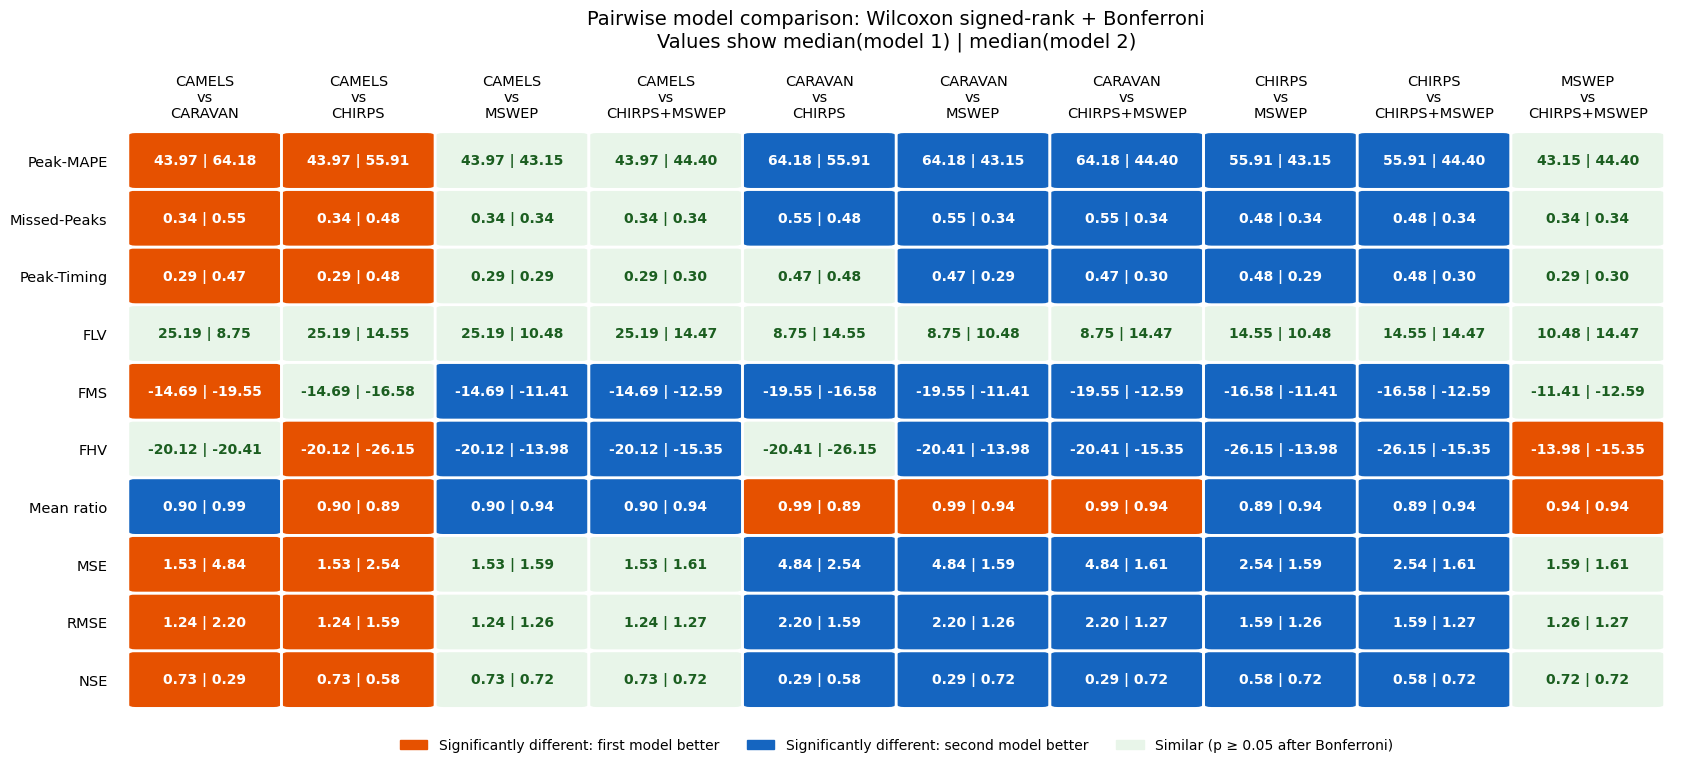

In [79]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import itertools

# ── 1. Define models ──────────────────────────────────────────────────────────
models      = ['camels', 'caravan', 'chirps', 'mswep', 'chirps_mswep']
short_names = ['CAMELS', 'CARAVAN', 'CHIRPS', 'MSWEP', 'CHIRPS+MSWEP']

# ── 2. Define targets (used in posthoc_wilcoxon to compute 'better') ──────────
metric_targets = {
    'NSE':          1,
    'RMSE':         0,
    'MSE':          0,
    'Beta-KGE':     1,
    'FHV':          0,
    'FMS':          0,
    'FLV':          0,
    'Peak-Timing':  0,
    'Missed-Peaks': 0,
    'Peak-MAPE':    0,
}

# ── 3. Friedman p-values (all significant for this basin set) ─────────────────
friedman_ps = {
    'NSE':          0.0000,
    'RMSE':         0.0000,
    'MSE':          0.0000,
    'Beta-KGE':     0.0000,
    'FHV':          0.0000,
    'FMS':          0.0000,
    'FLV':          0.0000,
    'Peak-Timing':  0.0000,
    'Missed-Peaks': 0.0000,
    'Peak-MAPE':    0.0000,
}

# ── 4. Re-run post-hoc ────────────────────────────────────────────────────────
posthoc_results = {}
for metric, df in metric_dfs.items():
    result = posthoc_wilcoxon(df, metric, friedman_ps[metric], metric_targets)
    if result is not None:
        posthoc_results[metric] = result

metric_dfs['Mean ratio']      = metric_dfs.pop('Beta-KGE')
posthoc_results['Mean ratio'] = posthoc_results.pop('Beta-KGE')
friedman_ps['Mean ratio']     = friedman_ps.pop('Beta-KGE')  # ← add this

# ── 5. Helper: get color key from posthoc_results ─────────────────────────────
skipped_metrics = [m for m, p in friedman_ps.items() if p >= 0.05]

def get_color_key(metric, m1, m2):
    res     = posthoc_results[metric]
    row     = res[(res['model_1'] == m1) & (res['model_2'] == m2)]
    flipped = False
    if row.empty:
        row     = res[(res['model_1'] == m2) & (res['model_2'] == m1)]
        flipped = True
    if row.empty:
        return 'tie'
    better = row['better'].values[0]
    if better == 'tie':
        return 'tie'
    if not flipped:
        return 'first'  if better == m1 else 'second'
    else:
        return 'first'  if better == m2 else 'second'

# ── 6. Build plot structures ──────────────────────────────────────────────────

metrics_list = ['NSE', 'RMSE', 'MSE', 'Mean ratio', 'FHV', 'FMS', 'FLV',  # ← changed
                'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

# metrics_list = ['NSE', 'RMSE', 'MSE', 'Beta-KGE', 'FHV', 'FMS', 'FLV',
#                 'Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']
pairs        = list(itertools.combinations(range(len(models)), 2))
pair_labels  = [f"{short_names[i]}\nvs\n{short_names[j]}" for i, j in pairs]
median_vals  = {metric: df.median() for metric, df in metric_dfs.items()}

# ── 7. Colors ─────────────────────────────────────────────────────────────────
colors = {
    0:        '#e8f5e9',
    2:        '#eeeeee',
    'first':  '#e65100',
    'second': '#1565c0',
    'tie':    '#6a1de8',
}
text_colors = {
    0:        '#1b5e20',
    2:        '#757575',
    'first':  'white',
    'second': 'white',
    'tie':    'white',
}

# ── 8. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(17, 8))
fig.patch.set_facecolor('white')

for m_idx, metric in enumerate(metrics_list):
    for p_idx, (i, j) in enumerate(pairs):
        m1, m2 = models[i], models[j]
        med_i  = median_vals[metric][m1]
        med_j  = median_vals[metric][m2]

        if metric in skipped_metrics:
            color_key = 2                              # Friedman n.s. → grey
        else:
            res    = posthoc_results[metric]
            row    = res[((res['model_1'] == m1) & (res['model_2'] == m2)) |
                         ((res['model_1'] == m2) & (res['model_2'] == m1))]
            is_sig = row['significant'].values[0] if not row.empty else False
            color_key = get_color_key(metric, m1, m2) if is_sig else 0

        rect = mpatches.FancyBboxPatch(
            (p_idx - 0.45, m_idx - 0.45), 0.9, 0.9,
            boxstyle="round,pad=0.05",
            facecolor=colors[color_key],
            edgecolor='white', linewidth=2
        )
        ax.add_patch(rect)

        label = f"{med_i:.2f} | {med_j:.2f}"
        ax.text(p_idx, m_idx, label,
                ha='center', va='center',
                fontsize=10, color=text_colors[color_key],
                fontweight='bold')

ax.set_xlim(-0.6, len(pairs) - 0.4)
ax.set_ylim(-0.6, len(metrics_list) - 0.4)
ax.set_xticks(range(len(pairs)))
ax.set_xticklabels(pair_labels, fontsize=10.5, ha='center')
ax.set_yticks(range(len(metrics_list)))
ax.set_yticklabels(metrics_list, fontsize=10.5)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', length=0, pad=4)
ax.tick_params(axis='y', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

legend_patches = [
    mpatches.Patch(color=colors['first'],  label='Significantly different: first model better'),
    mpatches.Patch(color=colors['second'], label='Significantly different: second model better'),
    mpatches.Patch(color=colors[0],        label='Similar (p ≥ 0.05 after Bonferroni)'),
    # mpatches.Patch(color=colors[2],        label='Not tested (Friedman n.s.)'),
]

ax.set_title(
    'Pairwise model comparison: Wilcoxon signed-rank + Bonferroni\n'
    'Values show median(model 1) | median(model 2)',
    fontsize=14, pad=20, fontweight='normal'
)
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.02), ncol=4,
          frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
# plt.savefig('wilcoxon_heatmap_us.png', dpi=150, bbox_inches='tight')
plt.show()